In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

In [13]:
init_iterNorm = np.load('../attach/init_after_iterNorm_all.npy')
cov_iterNorm = np.load('../attach/covariance_matrix_iterNorm_all.npy')

init_noIterNorm = np.load('../attach/init_after_noIterNorm_all.npy')
cov_noIterNorm = np.load('../attach/covariance_matrix_noIterNorm_all.npy')


In [15]:
init_iterNorm.shape, init_noIterNorm.shape, cov_iterNorm.shape, cov_noIterNorm.shape

((426, 32, 7, 96), (426, 32, 7, 96), (426, 96, 96), (426, 96, 96))

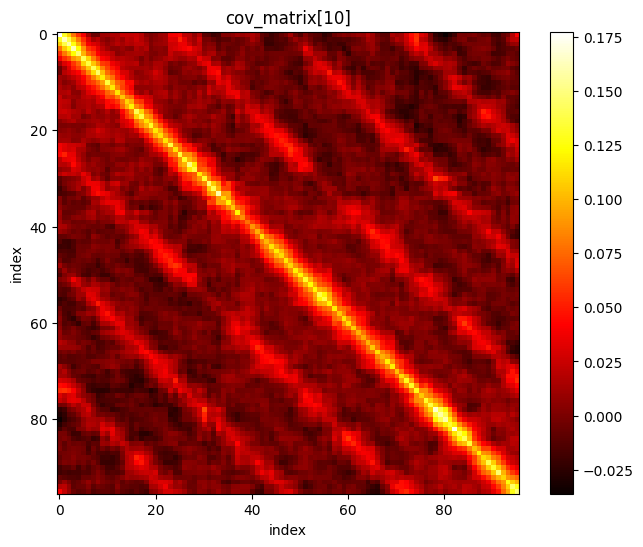

In [18]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_iterNorm[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_matrix[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()


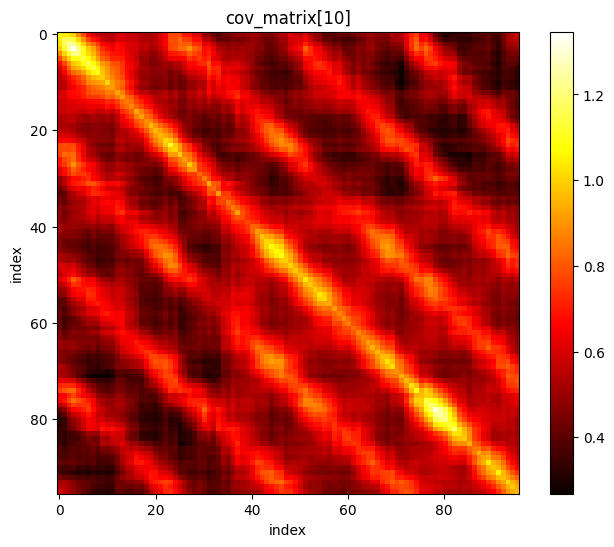

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_noIterNorm[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_matrix[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

In [20]:
init_iterNorm_T10 = np.load('../attach/init_after_iterNorm_T10_all.npy')
cov_iterNorm_T10 = np.load('../attach/covariance_matrix_iterNorm_T10_all.npy')


In [21]:
init_iterNorm_T10.shape, cov_iterNorm_T10.shape

((426, 32, 7, 96), (426, 96, 96))

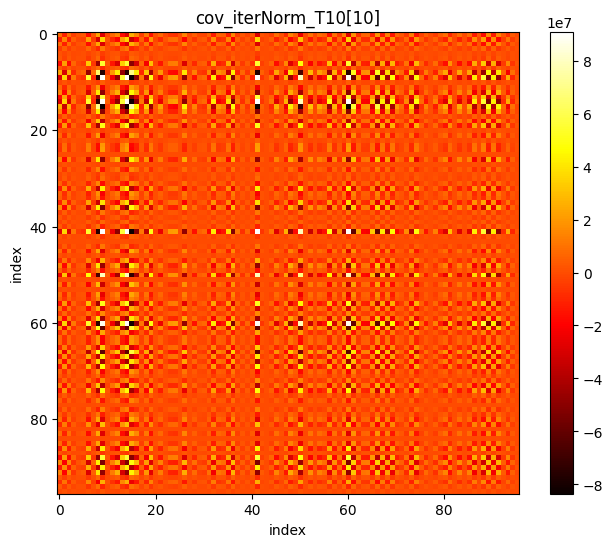

In [22]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_iterNorm_T10[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_iterNorm_T10[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

In [23]:
init_iterNorm_T7 = np.load('../attach/init_after_iterNorm_T7_all.npy')
cov_iterNorm_T7 = np.load('../attach/covariance_matrix_iterNorm_T7_all.npy')


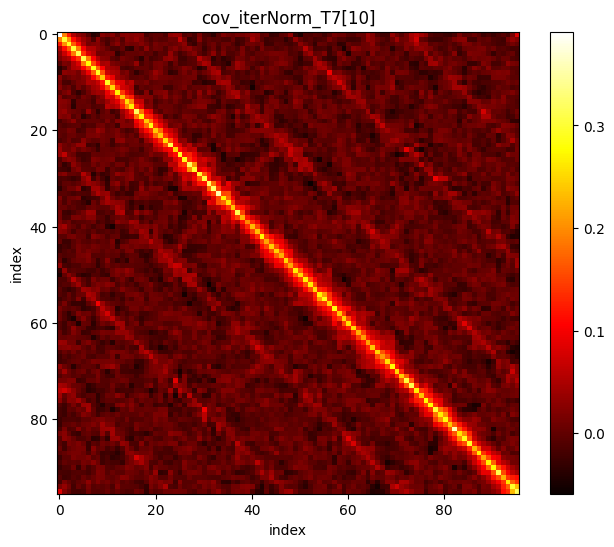

In [24]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_iterNorm_T7[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_iterNorm_T7[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

In [37]:
init_iterNorm_T7_train = np.load('../attach/init_after_iterNorm_T7_train_all.npy')
cov_iterNorm_T7_train = np.load('../attach/covariance_matrix_iterNorm_T7_train_all.npy')

init_iterNorm_T7_test = np.load('../attach/init_after_iterNorm_T7_test_all.npy')
cov_iterNorm_T7_test = np.load('../attach/covariance_matrix_iterNorm_T7_test_all.npy')


In [38]:
init_iterNorm_T7_train.shape, init_iterNorm_T7_test.shape, cov_iterNorm_T7_train.shape, cov_iterNorm_T7_test.shape

((375, 32, 7, 96), (3389, 1, 7, 96), (375, 96, 96), (3389, 96, 96))

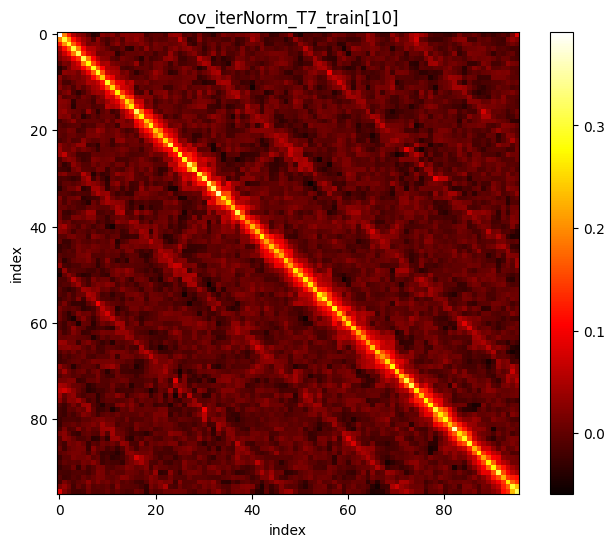

In [39]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_iterNorm_T7_train[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_iterNorm_T7_train[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

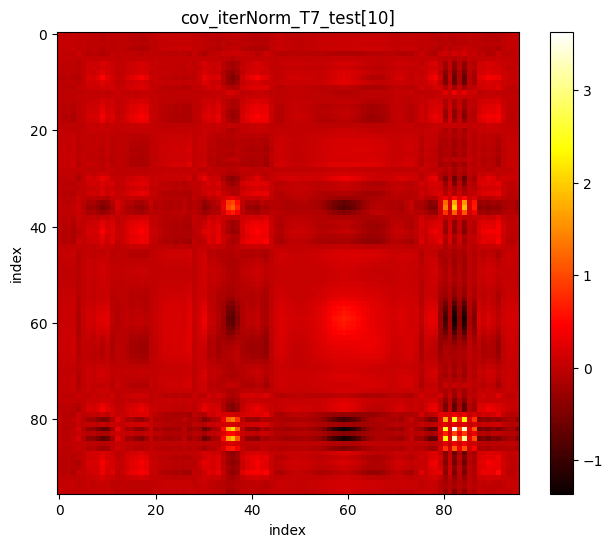

In [28]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_iterNorm_T7_test[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_iterNorm_T7_test[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

In [40]:
# 先将init_iterNorm_T7_test reshape 成 (num_batches, 32, 7, 96)
num_batches = init_iterNorm_T7_test.shape[0] // 32
init_test_reshaped = init_iterNorm_T7_test[:num_batches*32].reshape(num_batches, 32, 7, 96)

# 合并batch和通道维度，得到 (num_batches, 32*7, 96)
init_test_flat = init_test_reshaped.reshape(num_batches, 32*7, 96)

# 计算每个batch的协方差矩阵，结果为 (num_batches, 96, 96)
cov_test_from_init = np.stack([np.cov(batch, rowvar=False) for batch in init_test_flat], axis=0)

# 输出形状，应该和 cov_iterNorm_T7_train 类似
cov_test_from_init.shape

(105, 96, 96)

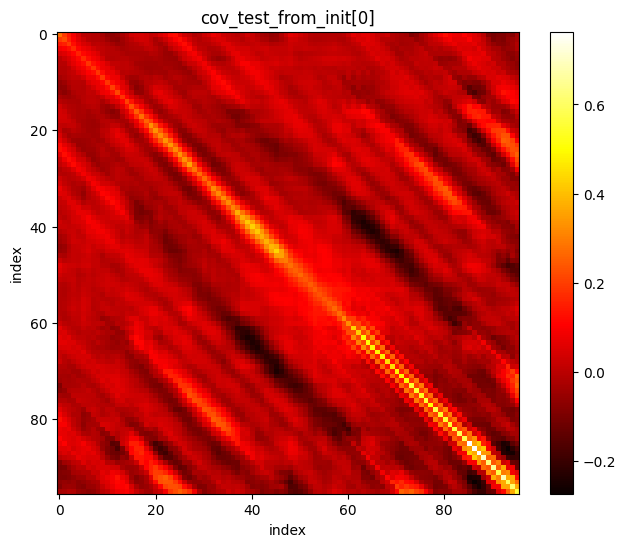

In [41]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_test_from_init[0], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_test_from_init[0]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

In [42]:
init_noIterNorm_T7_train = np.load('../attach/init_after_noIterNorm_T7_train_all.npy')
cov_noIterNorm_T7_train = np.load('../attach/covariance_matrix_noIterNorm_T7_train_all.npy')

init_noIterNorm_T7_test = np.load('../attach/init_after_noIterNorm_T7_test_all.npy')
cov_noIterNorm_T7_test = np.load('../attach/covariance_matrix_noIterNorm_T7_test_all.npy')


In [44]:
init_noIterNorm_T7_train.shape, init_noIterNorm_T7_test.shape, cov_noIterNorm_T7_train.shape, cov_noIterNorm_T7_test.shape

((375, 32, 7, 96), (3389, 1, 7, 96), (375, 96, 96), (3389, 96, 96))

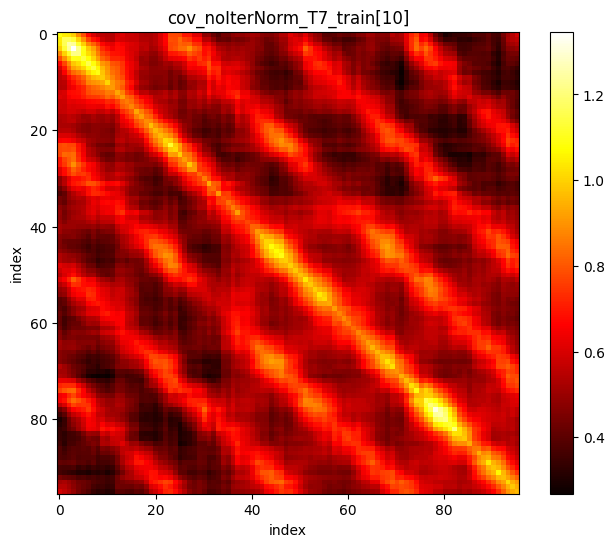

In [45]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_noIterNorm_T7_train[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_noIterNorm_T7_train[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()

In [46]:
# 先将init_noIterNorm_T7_test reshape 成 (num_batches, 32, 7, 96)
num_batches = init_noIterNorm_T7_test.shape[0] // 32
init_test_reshaped = init_noIterNorm_T7_test[:num_batches*32].reshape(num_batches, 32, 7, 96)

# 合并batch和通道维度，得到 (num_batches, 32*7, 96)
init_test_flat = init_test_reshaped.reshape(num_batches, 32*7, 96)

# 计算每个batch的协方差矩阵，结果为 (num_batches, 96, 96)
cov_test_from_init = np.stack([np.cov(batch, rowvar=False) for batch in init_test_flat], axis=0)

# 输出形状，应该和 cov_iterNorm_T7_train 类似
cov_test_from_init.shape

(105, 96, 96)

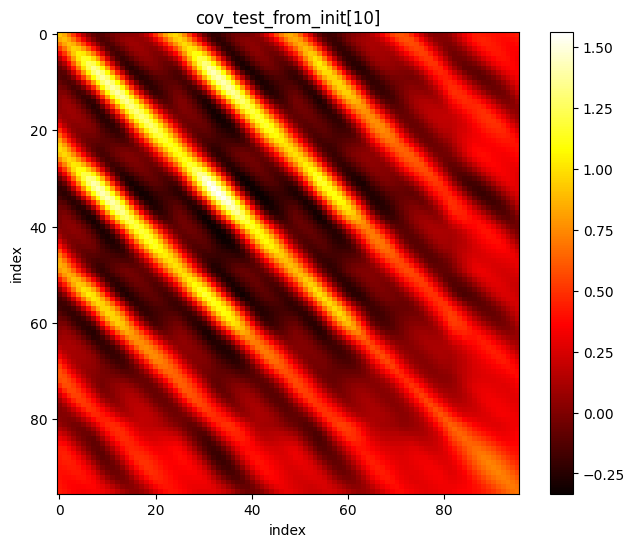

In [48]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_test_from_init[10], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('cov_test_from_init[10]')
plt.xlabel('index')
plt.ylabel('index')
plt.show()